# 🔫 Gunshot Trimmer — Maximum Verified Gunshot Extraction

Extracts every **genuine gunshot event** from all source data. Zero tolerance for false positives.

## What This Notebook Does
1. Scans `Data/gun/` and `Data/edge-collected-gunshot-audio/`
2. Uses multi-onset detection to find **every gunshot spike** (up to 8 per file)
3. Only extracts clips with real onsets — if a file has 1 gunshot, it takes 1. If 0, it takes 0.
4. Validates every clip with strict quality gates (peak, RMS, crest, spectral centroid, ZCR)
5. Every output clip is **exactly 250ms** (5,512 samples @ 22,050 Hz)

## Output
- `Data/TRIMMED_GUNSHOTS/verified/` ← All confirmed gunshot clips
- `Data/TRIMMED_GUNSHOTS/rejected/` ← Clips that failed quality checks
- `Data/TRIMMED_GUNSHOTS/reports/` ← manifest.csv + summary.json

See `manual/README.md` for the full documentation.

In [1]:
# ============================================================
# CELL 1: Install Dependencies
# ============================================================
%pip install -q librosa soundfile pandas numpy tqdm matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# CELL 2: Imports
# ============================================================
import librosa
import librosa.display
import numpy as np
import pandas as pd
import soundfile as sf
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings
import json
import shutil
import random
import re
import IPython.display as ipd

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
print('✅ All imports loaded successfully.')

✅ All imports loaded successfully.


c:\ProgramData\anaconda3\envs\guns\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ============================================================
# CELL 3: CONFIGURATION — CHANGE PATHS HERE
# ============================================================

# --- Path Auto-Detection ---
# This walks up from the notebook's location to find the project root.
# If it fails, hardcode PROJECT_ROOT below.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'Data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

# !! TO HARDCODE: Uncomment the line below and set your path !!
# PROJECT_ROOT = Path(r'd:\Desktop\Data-Cleaner')

DATA_DIR = PROJECT_ROOT / 'Data'
OUTPUT_DIR = DATA_DIR / 'TRIMMED_GUNSHOTS'

# --- Audio Parameters ---
SAMPLE_RATE = 22050            # All audio resampled to this
TARGET_MS = 250                # Every clip will be EXACTLY this long
TARGET_SAMPLES = int(SAMPLE_RATE * TARGET_MS / 1000)  # = 5512 samples

PRE_EVENT_MS = 50              # Grab 50ms BEFORE the gunshot onset
PRE_EVENT_SAMPLES = int(SAMPLE_RATE * PRE_EVENT_MS / 1000)

MAX_CLIPS_PER_FILE = 8         # Max onsets to extract per source file

# --- Source Directories ---
# These folders contain raw gunshot recordings (Class 1)
CLASS1_DIRS = [DATA_DIR / 'gun', DATA_DIR / 'edge-collected-gunshot-audio']

# --- Quality Gate Thresholds ---
PEAK_MIN = 0.01                # Minimum peak amplitude
RMS_MIN = 0.002                # Minimum RMS energy
CREST_MIN = 3.0                # Minimum crest factor (peak/RMS)
PROMINENCE_MIN = 4.0           # Peak must stand out above median
P95_MIN = 0.002                # 95th percentile minimum
CENTROID_MIN = 1500.0          # Spectral centroid minimum (Hz)

# --- Clean previous output? ---
OVERWRITE = True               # Set False to append to existing output

# --- Print config ---
print(f'Project Root    : {PROJECT_ROOT}')
print(f'Data Directory  : {DATA_DIR}')
print(f'Output          : {OUTPUT_DIR}')
print(f'Clip Duration   : {TARGET_MS}ms = {TARGET_SAMPLES} samples @ {SAMPLE_RATE}Hz')
print(f'Max Clips/File  : {MAX_CLIPS_PER_FILE}')
print(f'Overwrite       : {OVERWRITE}')
assert DATA_DIR.exists(), f'❌ Data directory not found: {DATA_DIR}'

Project Root    : C:\order\Desktop\Data-Cleaner
Data Directory  : C:\order\Desktop\Data-Cleaner\Data
Output          : C:\order\Desktop\Data-Cleaner\Data\TRIMMED_GUNSHOTS
Clip Duration   : 250ms = 5512 samples @ 22050Hz
Max Clips/File  : 8
Overwrite       : True


In [4]:
# ============================================================
# CELL 4: Helper Functions
# ============================================================
JUNK_TOKENS = ('__MACOSX',)
SAFE_NAME_RE = re.compile(r'[^A-Za-z0-9._-]+')


def is_junk(path):
    """Skip macOS junk files."""
    as_str = str(path)
    if any(token in as_str for token in JUNK_TOKENS):
        return True
    if path.name.startswith('._'):
        return True
    return False


def sanitize_name(raw, max_len=120):
    """Clean a filename for safe output."""
    cleaned = SAFE_NAME_RE.sub('_', raw.strip())
    cleaned = cleaned.strip('._')
    return (cleaned or 'clip')[:max_len]


def collect_wavs(dirs):
    """Collect all .wav files from a list of directories."""
    files = []
    for d in dirs:
        if d.exists():
            files.extend([f for f in d.rglob('*.wav') if not is_junk(f)])
    return sorted(files)


def load_audio(path):
    """Load a WAV file, resample to SAMPLE_RATE, convert to mono, clean NaN/Inf."""
    y, _ = librosa.load(str(path), sr=SAMPLE_RATE, mono=True)
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
    return y.astype(np.float32)


def force_exact_length(clip):
    """Guarantee the clip is EXACTLY TARGET_SAMPLES long. No exceptions."""
    if len(clip) == TARGET_SAMPLES:
        return clip
    if len(clip) > TARGET_SAMPLES:
        return clip[:TARGET_SAMPLES]
    return np.pad(clip, (0, TARGET_SAMPLES - len(clip)), mode='constant')


def normalize_clip(clip):
    """DC-offset removal + peak normalization to 0.999."""
    clip = clip - np.mean(clip)
    peak = float(np.max(np.abs(clip))) if len(clip) else 0.0
    if peak > 0.999:
        clip = clip / peak * 0.999
    return clip.astype(np.float32)


def write_clip(path, clip):
    """Write a clip to disk as 16-bit PCM WAV."""
    path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(str(path), clip, SAMPLE_RATE, subtype='PCM_16')
    if not path.exists() or path.stat().st_size <= 44:
        raise IOError(f'Empty/invalid file written: {path}')


print('✅ Helper functions defined.')

✅ Helper functions defined.


In [5]:
# ============================================================
# CELL 5: Multi-Onset Gunshot Detection (Enhanced Sniper Method)
# ============================================================

def find_gunshot_onsets(y):
    """
    Find all candidate gunshot onset positions in the audio.
    Uses three detection methods simultaneously, then ranks by strength.
    
    Returns: list of center sample positions, ordered by strength (strongest first).
    Returns empty list if no viable candidates found.
    """
    if y is None or len(y) < 100:
        return []
    
    abs_y = np.abs(y)
    
    # --- Method 1: Onset detection (spectral flux) ---
    hop = 128
    onset_env = librosa.onset.onset_strength(y=y, sr=SAMPLE_RATE, hop_length=hop)
    onset_frames = librosa.onset.onset_detect(
        onset_envelope=onset_env, sr=SAMPLE_RATE, hop_length=hop,
        backtrack=False, pre_max=3, post_max=3, pre_avg=3, post_avg=3,
        delta=0.1, wait=2
    )
    onset_samples = [int(f * hop) for f in onset_frames]
    
    # --- Method 2: Raw peak ---
    peak_raw = int(np.argmax(abs_y))
    
    # --- Method 3: Smoothed envelope peak ---
    smooth_kernel = max(3, int(0.005 * SAMPLE_RATE))
    kernel = np.ones(smooth_kernel, dtype=np.float32) / smooth_kernel
    envelope = np.convolve(abs_y, kernel, mode='same')
    peak_env = int(np.argmax(envelope))
    
    # --- Combine and score all candidates ---
    candidates = [peak_raw, peak_env] + onset_samples
    diff = np.abs(np.diff(y, prepend=0.0))
    
    scores = {}
    for c in candidates:
        if 0 <= c < len(y):
            scores[c] = float(abs_y[c]) + float(diff[c])
    
    # Sort by score (strongest first)
    sorted_candidates = [c for c, _ in sorted(scores.items(), key=lambda kv: kv[1], reverse=True)]
    
    # --- Filter overlapping candidates (minimum gap) ---
    min_gap = max(TARGET_SAMPLES // 2, int(SAMPLE_RATE * 0.03))
    filtered = []
    for c in sorted_candidates:
        if all(abs(c - kept) >= min_gap for kept in filtered):
            filtered.append(c)
        if len(filtered) >= MAX_CLIPS_PER_FILE:
            break
    
    return filtered


def extract_clip_at_onset(y, center):
    """
    Extract a 250ms clip centered around the onset.
    Places the onset at the 50ms mark (PRE_EVENT_SAMPLES from start).
    """
    start = int(center) - PRE_EVENT_SAMPLES
    end = start + TARGET_SAMPLES
    
    # Handle edge cases
    pad_left = max(0, -start)
    pad_right = max(0, end - len(y))
    src_start = max(0, start)
    src_end = min(len(y), end)
    
    clip = y[src_start:src_end]
    if pad_left > 0 or pad_right > 0:
        clip = np.pad(clip, (pad_left, pad_right), mode='constant')
    
    clip = force_exact_length(clip)
    clip = normalize_clip(clip)
    return clip, src_start, src_end


print('✅ Onset detection functions defined.')

✅ Onset detection functions defined.


In [6]:
# ============================================================
# CELL 6: Strict Quality Gate
# ============================================================

def gunshot_quality_check(clip):
    """
    Multi-layered quality validation for gunshot clips.
    
    Returns: (passed: bool, reason: str, metrics: dict)
    """
    abs_clip = np.abs(clip)
    peak = float(np.max(abs_clip)) if len(abs_clip) else 0.0
    rms = float(np.sqrt(np.mean(np.square(clip)))) if len(clip) else 0.0
    crest = peak / (rms + 1e-12)
    median_abs = float(np.median(abs_clip)) if len(abs_clip) else 0.0
    prominence = peak / (median_abs + 1e-12)
    p95 = float(np.percentile(abs_clip, 95)) if len(abs_clip) else 0.0
    
    # Spectral centroid (frequency center of mass)
    try:
        centroid = float(np.mean(librosa.feature.spectral_centroid(
            y=clip, sr=SAMPLE_RATE)[0]))
    except Exception:
        centroid = 0.0
    
    # Zero-crossing rate in the attack phase (first 30% of clip)
    attack_len = max(1, int(len(clip) * 0.3))
    attack_phase = clip[PRE_EVENT_SAMPLES:PRE_EVENT_SAMPLES + attack_len]
    if len(attack_phase) > 1:
        zcr_attack = float(np.mean(librosa.feature.zero_crossing_rate(
            y=attack_phase)[0]))
    else:
        zcr_attack = 0.0
    
    metrics = {
        'peak': peak,
        'rms': rms,
        'crest_factor': crest,
        'prominence': prominence,
        'p95': p95,
        'spectral_centroid': centroid,
        'zcr_attack': zcr_attack,
        'median_abs': median_abs,
    }
    
    # --- Quality checks ---
    if peak < PEAK_MIN:
        return False, 'peak_too_low', metrics
    if rms < RMS_MIN:
        return False, 'rms_too_low', metrics
    if crest < CREST_MIN:
        return False, 'crest_too_low', metrics
    if prominence < PROMINENCE_MIN:
        return False, 'prominence_too_low', metrics
    if p95 < P95_MIN:
        return False, 'too_quiet', metrics
    if centroid < CENTROID_MIN:
        return False, 'centroid_too_low', metrics
    
    return True, 'accepted', metrics


print('✅ Quality gate defined.')

✅ Quality gate defined.


In [7]:
# ============================================================
# CELL 7: BUILD PIPELINE — Run the full extraction
# ============================================================

def build_gunshot_dataset():
    """Main pipeline: extract, validate, and write all gunshot clips."""
    
    # --- Setup output directories ---
    if OUTPUT_DIR.exists() and OVERWRITE:
        shutil.rmtree(OUTPUT_DIR)
    
    verified_dir = OUTPUT_DIR / 'verified'
    rejected_dir = OUTPUT_DIR / 'rejected'
    reports_dir = OUTPUT_DIR / 'reports'
    
    verified_dir.mkdir(parents=True, exist_ok=True)
    rejected_dir.mkdir(parents=True, exist_ok=True)
    reports_dir.mkdir(parents=True, exist_ok=True)
    
    # --- Collect source files ---
    source_files = collect_wavs(CLASS1_DIRS)
    print(f'\n{"=" * 65}')
    print(f'GUNSHOT TRIMMER — Starting Build')
    print(f'{"=" * 65}')
    print(f'Source files found  : {len(source_files):,}')
    print(f'Output directory    : {OUTPUT_DIR}')
    print(f'Clip duration       : {TARGET_MS}ms ({TARGET_SAMPLES} samples)')
    print(f'Max clips per file  : {MAX_CLIPS_PER_FILE}')
    print(f'{"=" * 65}\n')
    
    manifest_rows = []
    rejected_log = []
    verified_count = 0
    rejected_count = 0
    skipped_files = 0
    clip_index = 0
    
    for src_path in tqdm(source_files, desc='🔫 Extracting gunshots', unit='file'):
        src_stem = sanitize_name(src_path.stem)
        src_parent = sanitize_name(src_path.parent.name)
        source_key = f'{src_parent}_{src_stem}'
        
        # Load audio
        try:
            y = load_audio(src_path)
        except Exception as exc:
            rejected_log.append({
                'source_path': str(src_path),
                'reason': f'load_error: {exc}',
            })
            skipped_files += 1
            continue
        
        if len(y) < 4:
            rejected_log.append({
                'source_path': str(src_path),
                'reason': 'too_short',
            })
            skipped_files += 1
            continue
        
        # Find all onset candidates
        onsets = find_gunshot_onsets(y)
        
        if not onsets:
            # No viable candidates at all — skip entirely
            skipped_files += 1
            continue
        
        # Extract and validate each candidate
        accepted_for_file = 0
        for k, center in enumerate(onsets):
            clip, src_start, src_end = extract_clip_at_onset(y, center)
            passed, reason, metrics = gunshot_quality_check(clip)
            
            if passed:
                clip_index += 1
                out_name = f'c1_{clip_index:07d}_{source_key}_k{k:02d}.wav'
                out_path = verified_dir / out_name
                write_clip(out_path, clip)
                verified_count += 1
                accepted_for_file += 1
                
                manifest_rows.append({
                    'output_path': str(out_path.relative_to(OUTPUT_DIR)),
                    'source_path': str(src_path),
                    'source_dir': src_parent,
                    'label': 1,
                    'candidate_index': k,
                    'start_sample': src_start,
                    'end_sample': src_end,
                    'duration_ms': TARGET_MS,
                    'sample_rate': SAMPLE_RATE,
                    'decision': 'accepted',
                    **metrics,
                })
            else:
                rejected_count += 1
                rej_name = f'rej_{rejected_count:07d}_{source_key}_k{k:02d}_{reason}.wav'
                rej_path = rejected_dir / rej_name
                write_clip(rej_path, clip)
                
                manifest_rows.append({
                    'output_path': str(rej_path.relative_to(OUTPUT_DIR)),
                    'source_path': str(src_path),
                    'source_dir': src_parent,
                    'label': 'rejected',
                    'candidate_index': k,
                    'start_sample': src_start,
                    'end_sample': src_end,
                    'duration_ms': TARGET_MS,
                    'sample_rate': SAMPLE_RATE,
                    'decision': reason,
                    **metrics,
                })
    
    # --- Save reports ---
    manifest_df = pd.DataFrame(manifest_rows)
    manifest_df.to_csv(reports_dir / 'manifest.csv', index=False)
    
    if rejected_log:
        pd.DataFrame(rejected_log).to_csv(reports_dir / 'skipped_sources.csv', index=False)
    
    summary = {
        'total_source_files': len(source_files),
        'skipped_source_files': skipped_files,
        'verified_clips': verified_count,
        'rejected_clips': rejected_count,
        'total_clips_extracted': verified_count + rejected_count,
        'config': {
            'sample_rate': SAMPLE_RATE,
            'target_ms': TARGET_MS,
            'target_samples': TARGET_SAMPLES,
            'max_clips_per_file': MAX_CLIPS_PER_FILE,
            'peak_min': PEAK_MIN,
            'rms_min': RMS_MIN,
            'crest_min': CREST_MIN,
            'prominence_min': PROMINENCE_MIN,
            'centroid_min': CENTROID_MIN,
        },
    }
    (reports_dir / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
    
    # --- Print results ---
    print(f'\n{"=" * 65}')
    print(f'BUILD COMPLETE')
    print(f'{"=" * 65}')
    print(f'✅ Verified gunshot clips  : {verified_count:,}')
    print(f'❌ Rejected clips          : {rejected_count:,}')
    print(f'⏭️  Skipped source files    : {skipped_files:,}')
    print(f'📁 Output                  : {OUTPUT_DIR}')
    print(f'{"=" * 65}')
    
    return manifest_df


# 🚀 RUN THE BUILD
manifest_df = build_gunshot_dataset()


GUNSHOT TRIMMER — Starting Build
Source files found  : 4,138
Output directory    : C:\order\Desktop\Data-Cleaner\Data\TRIMMED_GUNSHOTS
Clip duration       : 250ms (5512 samples)
Max clips per file  : 8



🔫 Extracting gunshots: 100%|██████████| 4138/4138 [01:36<00:00, 42.68file/s]



BUILD COMPLETE
✅ Verified gunshot clips  : 6,763
❌ Rejected clips          : 2,267
⏭️  Skipped source files    : 0
📁 Output                  : C:\order\Desktop\Data-Cleaner\Data\TRIMMED_GUNSHOTS


In [8]:
# ============================================================
# CELL 8: VERIFICATION — Check all files are exactly 250ms
# ============================================================
print('Verifying all output files...\n')

verified_files = list((OUTPUT_DIR / 'verified').glob('*.wav'))
rejected_files = list((OUTPUT_DIR / 'rejected').glob('*.wav'))

bad_files = []
for f in tqdm(verified_files + rejected_files, desc='Checking sizes'):
    y, sr = librosa.load(f, sr=None)
    if len(y) != TARGET_SAMPLES:
        bad_files.append((f.name, len(y)))

if bad_files:
    print(f'\n⚠️ WARNING: {len(bad_files)} files are NOT exactly {TARGET_SAMPLES} samples!')
    for name, length in bad_files[:10]:
        print(f'  {name}: {length} samples')
else:
    total = len(verified_files) + len(rejected_files)
    print(f'\n✅ ALL {total:,} files are exactly {TARGET_SAMPLES} samples ({TARGET_MS}ms). Perfect!')

print(f'\n📊 Summary:')
print(f'  Verified clips  : {len(verified_files):,}')
print(f'  Rejected clips  : {len(rejected_files):,}')
print(f'  Total output    : {len(verified_files) + len(rejected_files):,}')

# Rejection reason breakdown
if not manifest_df.empty:
    rejected_mask = manifest_df['decision'] != 'accepted'
    if rejected_mask.any():
        print(f'\n📝 Rejection reasons:')
        reasons = manifest_df.loc[rejected_mask, 'decision'].value_counts()
        for reason, count in reasons.items():
            print(f'  {reason:<25} : {count:,}')

Verifying all output files...



Checking sizes: 100%|██████████| 9030/9030 [00:01<00:00, 8580.86it/s]


✅ ALL 9,030 files are exactly 5512 samples (250ms). Perfect!

📊 Summary:
  Verified clips  : 6,763
  Rejected clips  : 2,267
  Total output    : 9,030

📝 Rejection reasons:
  centroid_too_low          : 760
  peak_too_low              : 703
  crest_too_low             : 425
  rms_too_low               : 344
  too_quiet                 : 30
  prominence_too_low        : 5


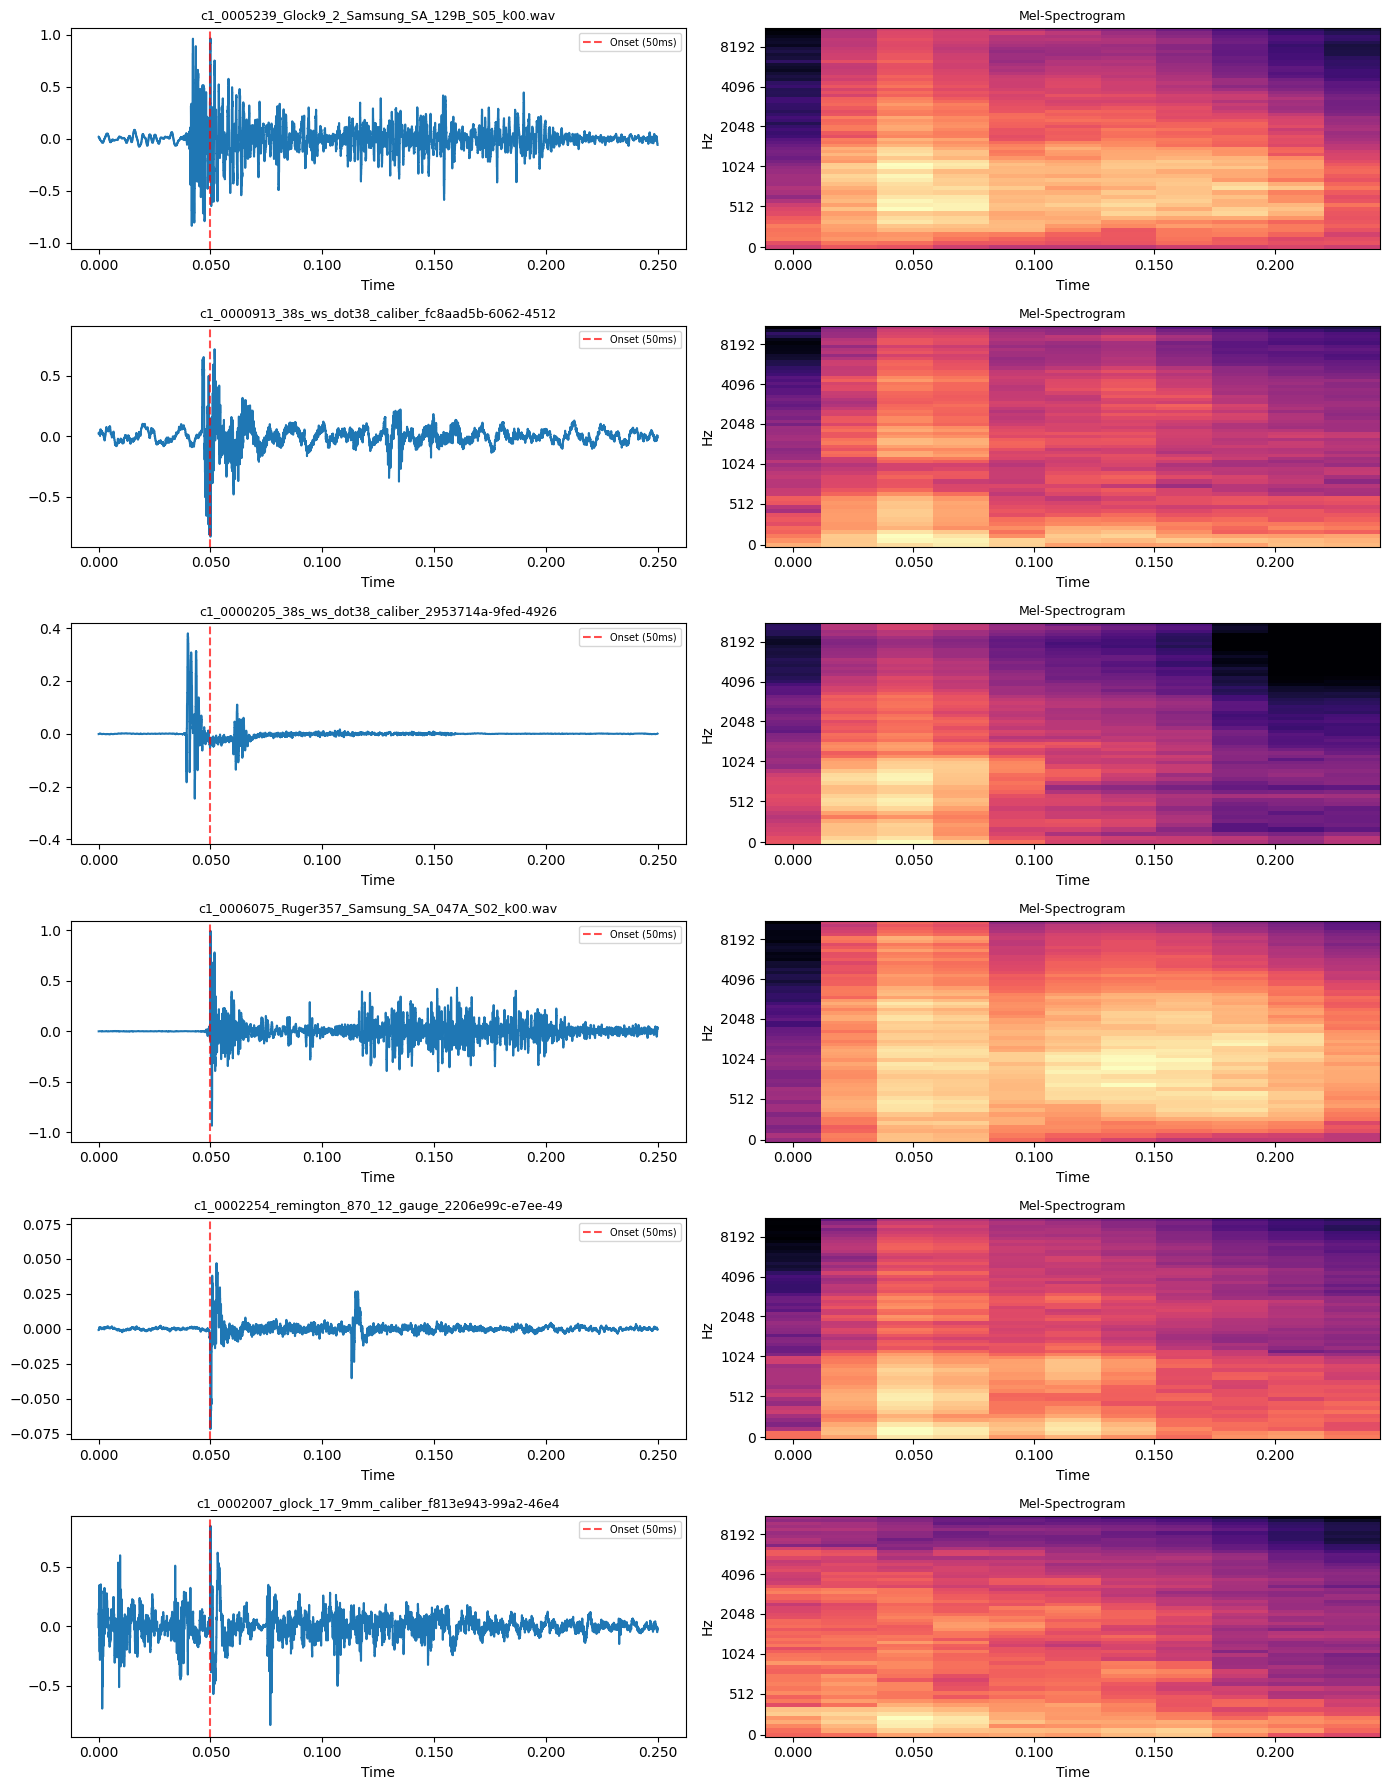


🔊 Listen to verified clips:
  c1_0005239_Glock9_2_Samsung_SA_129B_S05_k00.wav


  c1_0000913_38s_ws_dot38_caliber_fc8aad5b-6062-4512-8364-5ab905b2faea_v1_k00.wav


  c1_0000205_38s_ws_dot38_caliber_2953714a-9fed-4926-943f-466071b77cf4_mean_v0_k01.wav


In [9]:
# ============================================================
# CELL 9: VISUAL AUDIT — Plot random verified clips
# ============================================================
if not verified_files:
    print('No verified files to plot.')
else:
    n_samples = min(6, len(verified_files))
    sample_files = random.sample(verified_files, n_samples)
    
    fig, axes = plt.subplots(n_samples, 2, figsize=(14, 3 * n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, f in enumerate(sample_files):
        y, sr = librosa.load(f, sr=None)
        
        # Waveform
        librosa.display.waveshow(y, sr=sr, ax=axes[i, 0])
        axes[i, 0].set_title(f.name[:50], fontsize=9)
        axes[i, 0].axvline(x=PRE_EVENT_MS/1000, color='r', linestyle='--',
                           alpha=0.7, label='Onset (50ms)')
        axes[i, 0].legend(fontsize=7)
        
        # Mel spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        S_dB = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel',
                                ax=axes[i, 1])
        axes[i, 1].set_title('Mel-Spectrogram', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'reports' / 'visual_audit.png', dpi=150)
    plt.show()
    
    # Audio playback for first 3
    print('\n🔊 Listen to verified clips:')
    for f in sample_files[:3]:
        print(f'  {f.name}')
        display(ipd.Audio(f))